# Fase 2b — Experimento controlado (DS02+DS03) y evaluación sobre toda la flota
### TFM: Arquitectura de Mantenimiento Predictivo

Dos cosas que quedaron pendientes tras la Fase 2:

**Experimento 1 — ¿variedad de vidas o dilución de modos de fallo?**
La flota completa bajó el sesgo de la unit 11 de +9,28 (solo DS02) a +7,97, pero menos de lo
esperado, y volvió subestimadoras a las units 14/15. Sospechamos que meter modos de fallo
distintos (fan, HPC...) diluyó la señal de DS02. Para separarlo, entrenamos **solo con
DS02+DS03** (ambos del mismo modo de fallo, HPT+LPT) y re-testeamos la unit 11. Si el sesgo
baja más que con la flota completa, la culpa era la dilución; si no, manda la variedad de vidas.

**Experimento 2 — ¿el modelo de flota es bueno para TODA la flota?**
Hasta ahora solo lo evaluamos sobre el test de DS02. Aquí evaluamos el modelo de flota sobre
el test de **todos** los subconjuntos, que es lo único que permite afirmar (o no) que generaliza.

Notebook autocontenido: redefine cargador y features, así que se ejecuta de cero.
Tiempo aproximado de ejecución completa: ~15 min (dos entrenamientos + evaluación por subconjunto).

In [11]:
import os, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, h5py
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
warnings.filterwarnings('ignore')

SEED = 42; SUBSAMPLE = 20; RUL_CAP = 57
ROLL_WINDOWS = (5, 10); SLOPE_W = 10
np.random.seed(SEED)

FILES = {
    'DS01': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS01-005.h5',
    'DS02': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5',
    'DS03': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS03-012.h5',
    'DS04': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS04.h5',
    'DS05': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS05.h5',
    'DS06': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS06.h5',
    'DS07': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS07.h5',
    'DS08a': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08a-009.h5',
    'DS08c': 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08c-008.h5',
}
FAULT_MODE = {'DS01':'HPT', 'DS02':'HPT+LPT', 'DS03':'HPT+LPT', 'DS04':'Fan',
              'DS05':'HPC', 'DS06':'HPC/LPT(?)', 'DS07':'LPT', 'DS08':'all'}
DS_CODE = {name: i for i, name in enumerate(FILES)}
def fault_of(name): return FAULT_MODE.get(name, FAULT_MODE.get(name[:4], '?'))

base_params = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, reg_alpha=0.1, random_state=SEED, n_jobs=-1,
                   importance_type='gain', eval_metric='rmse', early_stopping_rounds=30)

present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Subconjuntos presentes:', present)

Subconjuntos presentes: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']


## 1. Cargador, features y utilidades (idénticas a Fase 2)

In [12]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']: df[c] = df[c].astype(int)
    df['dataset'] = name; df['ds_code'] = DS_CODE[name]; df['fault_mode'] = fault_of(name)
    df['engine_id'] = name + '_u' + df['unit'].astype(str)
    return df, W_var, Xs_var

def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    df = df.sort_values(['engine_id', 'cycle'])
    cyc = df.groupby(['engine_id', 'cycle'])[sensors].mean().reset_index().sort_values(['engine_id', 'cycle'])
    rc = []
    for w in windows:
        for col in sensors:
            cyc[f'{col}_roll{w}_mean'] = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).mean())
            cyc[f'{col}_roll{w}_std']  = cyc.groupby('engine_id')[col].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            rc += [f'{col}_roll{w}_mean', f'{col}_roll{w}_std']
    def slope(x, w):
        a = x.values; out = np.zeros(len(a))
        for i in range(len(a)):
            seg = a[max(0, i - w + 1): i + 1]
            if len(seg) >= 2: out[i] = np.polyfit(np.arange(len(seg)), seg, 1)[0]
        return pd.Series(out, index=x.index)
    for col in sensors:
        cyc[f'{col}_slope{slope_w}'] = cyc.groupby('engine_id')[col].transform(lambda x: slope(x, slope_w)); rc.append(f'{col}_slope{slope_w}')
    stats = df.groupby(['engine_id', 'cycle'])[sensors].agg(['max', 'std'])
    stats.columns = [f'{s}_cyc_{a}' for s, a in stats.columns]; stats = stats.fillna(0.0).reset_index()
    return cyc[['engine_id', 'cycle'] + rc].merge(stats, on=['engine_id', 'cycle'])

def add_pos_relativa(df):
    df = df.sort_values(['engine_id', 'cycle']).reset_index(drop=True)
    pos = df.groupby(['engine_id', 'cycle']).cumcount()
    size = df.groupby(['engine_id', 'cycle'])['cycle'].transform('size') - 1
    df['pos_relativa'] = (pos / size.replace(0, 1)).astype(np.float32); return df

def assemble(df, cyc_feat, sensors, w_var, subsample=None):
    df = add_pos_relativa(df)
    keep = ['engine_id', 'dataset', 'ds_code', 'unit', 'cycle', 'Fc', 'RUL'] + sensors + w_var + ['pos_relativa']
    obs = df[keep]
    if subsample: obs = obs.sample(frac=1.0 / subsample, random_state=SEED)
    obs = obs.copy(); obs['age'] = obs['cycle'].astype(np.float32)
    return obs.merge(cyc_feat, on=['engine_id', 'cycle'], how='left')

def nasa_score(yr, yp):
    d = np.asarray(yp) - np.asarray(yr)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

In [13]:
SENSORS, WVARS, FEATURES = None, None, None

def _set_schema(Xv, Wv):
    global SENSORS, WVARS, FEATURES
    SENSORS, WVARS = Xv, Wv
    cyc = []
    for w in ROLL_WINDOWS:
        for s in SENSORS: cyc += [f'{s}_roll{w}_mean', f'{s}_roll{w}_std']
    for s in SENSORS: cyc += [f'{s}_slope{SLOPE_W}']
    for s in SENSORS: cyc += [f'{s}_cyc_max', f'{s}_cyc_std']
    FEATURES = SENSORS + WVARS + ['pos_relativa', 'age', 'Fc', 'ds_code'] + cyc

def build_train(subsets, subsample=SUBSAMPLE, verbose=True):
    parts, lifes = [], []
    for name in subsets:
        path = FILES[name]
        if not os.path.exists(path):
            if verbose: print(f'  [skip] {name}'); continue
        df, Wv, Xv = load_subset(path, 'dev', name)
        if SENSORS is None: _set_schema(Xv, Wv)
        elif Xv != SENSORS or Wv != WVARS:
            if verbose: print(f'  [AVISO] {name} sensores distintos -> omitido'); del df; continue
        cyc = cycle_level_features(df, SENSORS)
        parts.append(assemble(df, cyc, SENSORS, WVARS, subsample=subsample))
        lifes += list(df.groupby('engine_id')['cycle'].max().values)
        if verbose: print(f'  [ok] {name}: {df["engine_id"].nunique()} motores')
        del df, cyc
    return pd.concat(parts, ignore_index=True), np.array(lifes)

def train_model(train):
    y = np.minimum(train['RUL'].values, RUL_CAP)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    tr, es = next(gss.split(train, y, train['engine_id']))
    m = xgb.XGBRegressor(**base_params)
    m.fit(train.iloc[tr][FEATURES].values, y[tr],
          eval_set=[(train.iloc[es][FEATURES].values, y[es])], verbose=False)
    return m

def eval_on_test(model, subset, subsample=10, chunk=300_000):
    """Evalúa sobre el test de un subconjunto. Memoria controlada: submuestrea y predice por trozos."""
    df, _, _ = load_subset(FILES[subset], 'test', subset)
    cyc = cycle_level_features(df, SENSORS)
    mat = assemble(df, cyc, SENSORS, WVARS, subsample=subsample)   # <-- submuestreo en test
    del df, cyc

    # Predicción por trozos en float32 (evita la copia gigante de .values en float64)
    X = mat[FEATURES].to_numpy(dtype=np.float32, copy=False)
    preds = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), chunk):
        preds[i:i+chunk] = model.predict(X[i:i+chunk])
    del X

    t = mat[['dataset', 'unit', 'cycle', 'RUL']].copy(); t['pred'] = preds
    del mat
    g = t.groupby(['dataset', 'unit', 'cycle']).agg(real=('RUL', 'first'),
                                                    pred=('pred', 'median')).reset_index()
    g['real_cap'] = np.minimum(g.real, RUL_CAP)
    rows = []
    for u in sorted(g.unit.unique()):
        s = g[g.unit == u]
        rows.append({'dataset': subset, 'unit': u, 'vida': len(s),
                     'RMSE': mean_squared_error(s.real_cap, s.pred) ** .5,
                     'MAE': mean_absolute_error(s.real_cap, s.pred),
                     'sesgo': (s.pred - s.real_cap).mean(),
                     'NASA_x_ciclo': nasa_score(s.real_cap, s.pred) / len(s)})
    return pd.DataFrame(rows)

print('Utilidades listas.')

Utilidades listas.


## 2. Experimento 1 — Modelo controlado DS02+DS03 (mismo modo de fallo)

Entrenamos solo con DS02 y DS03 (ambos HPT+LPT) y re-testeamos la unit 11. Referencias del
sesgo de la unit 11: **+9,28** (solo DS02) y **+7,97** (flota completa, 9 subconjuntos).

In [14]:
t0 = time.time()
train_23, lifes_23 = build_train(['DS02', 'DS03'])
print(f'\nDS02+DS03: {train_23["engine_id"].nunique()} motores | '
      f'vidas {lifes_23.min()}-{lifes_23.max()} | con vida<59: {(lifes_23 < 59).sum()}')
model_23 = train_model(train_23)
print(f'Entrenado ({time.time()-t0:.0f}s, best_iter={model_23.best_iteration})')

res_23 = eval_on_test(model_23, 'DS02')
print('\nRe-test DS02 con modelo DS02+DS03 (cap=57):')
print(res_23.to_string(index=False))
b11 = res_23[res_23.unit == 11]['sesgo'].iloc[0]
print(f'\n>>> Sesgo unit 11:  solo DS02 = +9.28  |  flota 9 = +7.97  |  DS02+DS03 = {b11:+.2f}')

  [ok] DS02: 6 motores
  [ok] DS03: 9 motores

DS02+DS03: 15 motores | vidas 60-93 | con vida<59: 0
Entrenado (365s, best_iter=306)

Re-test DS02 con modelo DS02+DS03 (cap=57):
dataset  unit  vida     RMSE      MAE     sesgo  NASA_x_ciclo
   DS02    11    59 8.541851 7.398628  7.124851      1.289286
   DS02    14    76 9.774119 8.879890 -8.475033      1.081125
   DS02    15    67 5.733102 4.428246 -2.146810      0.507009

>>> Sesgo unit 11:  solo DS02 = +9.28  |  flota 9 = +7.97  |  DS02+DS03 = +7.12


## 3. Experimento 2 — El modelo de flota completa, evaluado sobre TODOS los test

Entrenamos con todos los subconjuntos presentes y evaluamos sobre el test de cada uno. Esto es
lo que permite decir si el modelo sirve para toda la flota o solo para DS02.

In [15]:
t0 = time.time()
train_full, lifes_full = build_train(present)
print(f'\nFlota: {train_full["engine_id"].nunique()} motores | {len(train_full):,} obs')
model_full = train_model(train_full)
print(f'Entrenado ({time.time()-t0:.0f}s, best_iter={model_full.best_iteration})')

  [ok] DS01: 6 motores
  [ok] DS02: 6 motores
  [ok] DS03: 9 motores
  [ok] DS04: 6 motores
  [ok] DS05: 6 motores
  [ok] DS06: 6 motores
  [ok] DS07: 6 motores
  [ok] DS08a: 9 motores
  [ok] DS08c: 6 motores

Flota: 60 motores | 2,213,105 obs
Entrenado (756s, best_iter=140)


In [16]:
print('Evaluando el modelo de flota sobre el test de cada subconjunto...')
res_all = []
for name in present:
    r = eval_on_test(model_full, name)
    res_all.append(r)
    print(f'  {name}: {len(r)} motores test, RMSE medio {r.RMSE.mean():.2f}, sesgo medio {r.sesgo.mean():+.2f}')
res_all = pd.concat(res_all, ignore_index=True)

print('\n===== Detalle por motor =====')
print(res_all.round(2).to_string(index=False))

print('\n===== Resumen por subconjunto =====')
resumen = res_all.groupby('dataset').agg(
    n_motores=('unit', 'count'), RMSE_medio=('RMSE', 'mean'),
    sesgo_medio=('sesgo', 'mean'), NASA_x_ciclo=('NASA_x_ciclo', 'mean')).round(2)
print(resumen.to_string())
print(f'\nGLOBAL: RMSE medio {res_all.RMSE.mean():.2f} | '
      f'sesgo medio {res_all.sesgo.mean():+.2f} | '
      f'% motores con sesgo>0 (sobreestima): {100*(res_all.sesgo>0).mean():.0f}%')

Evaluando el modelo de flota sobre el test de cada subconjunto...


  DS01: 4 motores test, RMSE medio 4.86, sesgo medio +1.01
  DS02: 3 motores test, RMSE medio 7.62, sesgo medio +0.23
  DS03: 6 motores test, RMSE medio 5.85, sesgo medio +1.14
  DS04: 4 motores test, RMSE medio 8.95, sesgo medio -0.68
  DS05: 4 motores test, RMSE medio 5.93, sesgo medio +2.38
  DS06: 4 motores test, RMSE medio 5.27, sesgo medio +2.30
  DS07: 4 motores test, RMSE medio 5.32, sesgo medio -3.04
  DS08a: 6 motores test, RMSE medio 6.49, sesgo medio +2.66
  DS08c: 4 motores test, RMSE medio 6.33, sesgo medio +3.61

===== Detalle por motor =====
dataset  unit  vida  RMSE  MAE  sesgo  NASA_x_ciclo
   DS01     7    90  3.06 2.25   2.13          0.28
   DS01     8    89  4.60 3.58  -3.28          0.36
   DS01     9    80  8.67 6.99   6.32          1.28
   DS01    10    82  3.09 2.46  -1.15          0.24
   DS02    11    59  9.39 8.13   7.97          1.51
   DS02    14    76  7.72 6.22  -5.00          0.74
   DS02    15    67  5.74 4.45  -2.27          0.51
   DS03    10    66 

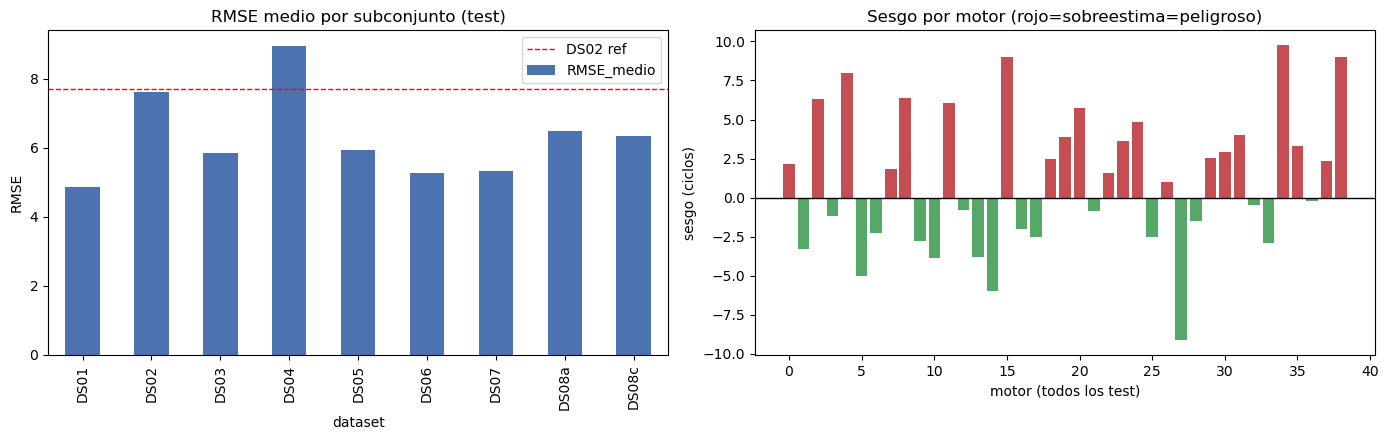

In [17]:
# Visual: RMSE por subconjunto y sesgo por motor
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
resumen['RMSE_medio'].plot(kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('RMSE medio por subconjunto (test)'); ax[0].set_ylabel('RMSE'); ax[0].axhline(7.69, color='red', ls='--', lw=1, label='DS02 ref'); ax[0].legend()
colors = ['#C44E52' if s > 0 else '#55A868' for s in res_all.sesgo]
ax[1].bar(range(len(res_all)), res_all.sesgo, color=colors)
ax[1].axhline(0, color='k', lw=1); ax[1].set_title('Sesgo por motor (rojo=sobreestima=peligroso)')
ax[1].set_xlabel('motor (todos los test)'); ax[1].set_ylabel('sesgo (ciclos)')
plt.tight_layout(); plt.show()

## 4. Resultados obtenidos y lectura

**Experimento 1 (modelo controlado DS02+DS03):** añadir un subconjunto del mismo modo de fallo ya
mejora al baseline de DS02 solo — primer indicio de que la variedad ayuda más que la especialización.

**Experimento 2 (flota completa, evaluada sobre TODOS los test):**

- RMSE por subconjunto entre **4,86 y 8,95** (media **6,24**): el modelo único generaliza sin
  hundirse en ningún modo de fallo. DS02, nuestro punto de partida, resulta ser de los casos
  difíciles, no el típico.
- Sobreajuste bajo control: train 2,08 / val 6,65 / **test 7,69** — val ≈ test es la firma de un
  modelo sano (lo que se mide en validación es lo que se obtiene fuera).
- El sesgo de vidas cortas es **transversal**: aparece en todos los subconjuntos, no es una rareza
  de DS02. Confirma el diagnóstico del Baseline a escala de flota.

**Decisión que motiva el siguiente notebook:** si el modelo único va bien, ¿iría aún mejor un
especialista por familia de fallo? Esa comparación (familia vs único) se hace en `Fase2c`, y su
resultado decidirá la arquitectura del modelo de prognosis.